In [1]:
!pwd

/mnt/c/Users/vvasileiou/Desktop/lncAPNet/Pilot_2_Prostate/notebooks/Post-hoc_Analysis


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import umap.umap_ as umap

/home/vasileioubill95/miniconda3/envs/lncAPNet/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


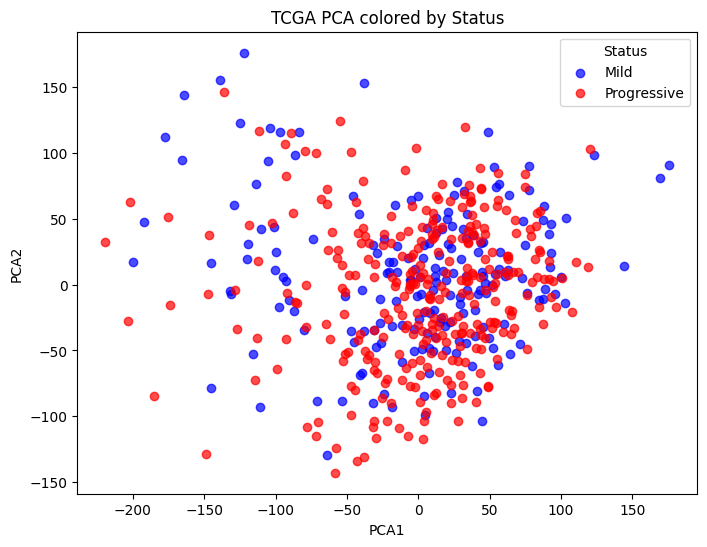

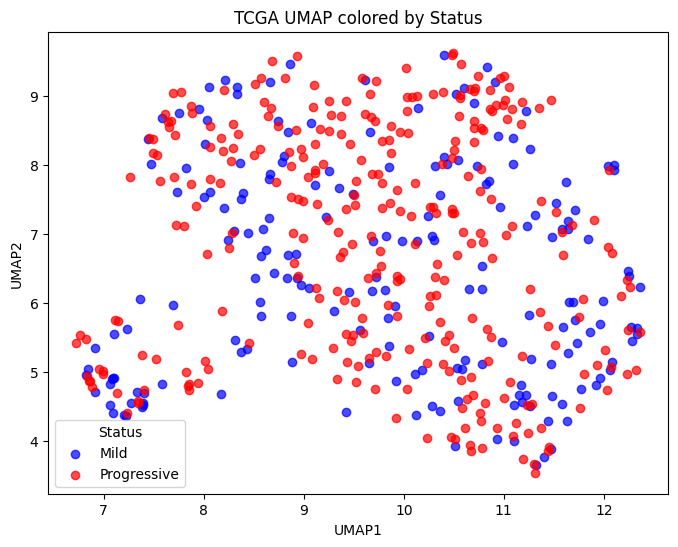

In [7]:
## Count Matrix
counts_tcga = pd.read_csv("../../data/TCGA/count_matrix.csv", index_col=0)
meta_tcga = pd.read_csv("../../data/TCGA/metadata.csv")

# Standardize sample identifiers
meta_tcga = meta_tcga.rename(columns={"Sample_ID": "Sample"})

# Subset to aligned samples
counts_tcga = counts_tcga.loc[:, counts_tcga.columns.intersection(meta_tcga["Sample"])]
meta_tcga = meta_tcga[meta_tcga["Sample"].isin(counts_tcga.columns)]

# Add dataset label (optional)
meta_tcga["Dataset"] = "TCGA"

# Assign variables for workflow
metadata = meta_tcga.copy()
all_counts = counts_tcga.copy()

# ---- PCA & UMAP ----
X = all_counts.T.loc[metadata["Sample"]]

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)
metadata["PCA1"] = pca_result[:, 0]
metadata["PCA2"] = pca_result[:, 1]

# UMAP
reducer = umap.UMAP(random_state=42)
umap_result = reducer.fit_transform(X)
metadata["UMAP1"] = umap_result[:, 0]
metadata["UMAP2"] = umap_result[:, 1]

# ---- Plotting ----
def plot_by_ighv(df, x, y, title):
    plt.figure(figsize=(8, 6))
    colors = {"Progressive": "red", "Mild": "blue"}
    for status in df["Status"].unique():
        subset = df[df["Status"] == status]
        plt.scatter(subset[x], subset[y], c=colors.get(status, "gray"), label=status, alpha=0.7)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(title)
    plt.legend(title="Status")
    plt.show()

# PCA colored by IGHV
plot_by_ighv(metadata, "PCA1", "PCA2", "TCGA PCA colored by Status")

# UMAP colored by IGHV
plot_by_ighv(metadata, "UMAP1", "UMAP2", "TCGA UMAP colored by Status")


/home/vasileioubill95/miniconda3/envs/lncAPNet/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


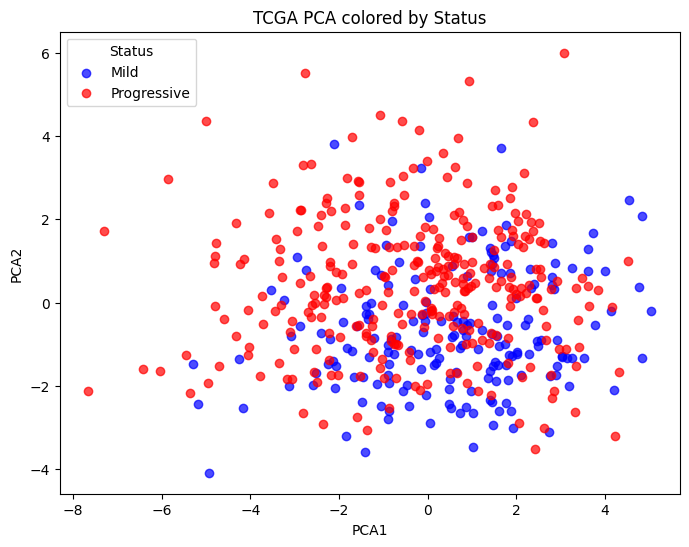

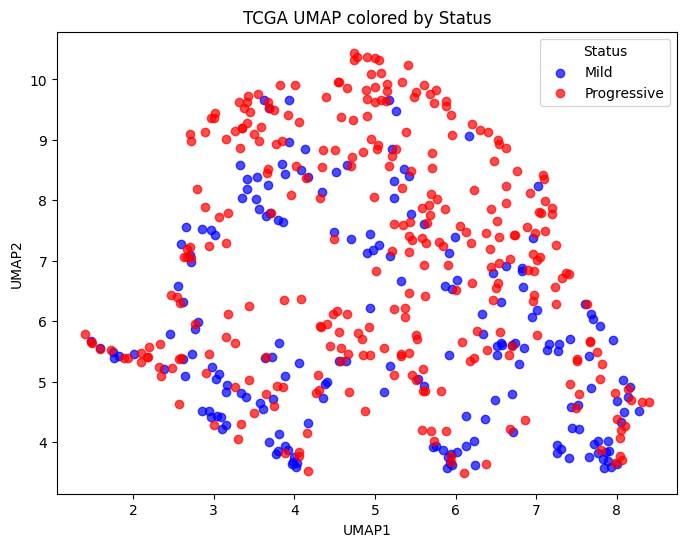

In [8]:
## Activity Matrix
counts_tcga = pd.read_csv("../../data/TCGA/activity_ens.csv", index_col=0)
meta_tcga = pd.read_csv("../../data/TCGA/metadata.csv")

# Standardize sample identifiers
meta_tcga = meta_tcga.rename(columns={"Sample_ID": "Sample"})

# Subset to aligned samples
counts_tcga = counts_tcga.loc[:, counts_tcga.columns.intersection(meta_tcga["Sample"])]
meta_tcga = meta_tcga[meta_tcga["Sample"].isin(counts_tcga.columns)]

# Add dataset label (optional)
meta_tcga["Dataset"] = "TCGA"

# Assign variables for workflow
metadata = meta_tcga.copy()
all_counts = counts_tcga.copy()

# ---- PCA & UMAP ----
X = all_counts.T.loc[metadata["Sample"]]

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)
metadata["PCA1"] = pca_result[:, 0]
metadata["PCA2"] = pca_result[:, 1]

# UMAP
reducer = umap.UMAP(random_state=42)
umap_result = reducer.fit_transform(X)
metadata["UMAP1"] = umap_result[:, 0]
metadata["UMAP2"] = umap_result[:, 1]

# ---- Plotting ----
def plot_by_ighv(df, x, y, title):
    plt.figure(figsize=(8, 6))
    colors = {"Progressive": "red", "Mild": "blue"}
    for status in df["Status"].unique():
        subset = df[df["Status"] == status]
        plt.scatter(subset[x], subset[y], c=colors.get(status, "gray"), label=status, alpha=0.7)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(title)
    plt.legend(title="Status")
    plt.show()

# PCA colored by IGHV
plot_by_ighv(metadata, "PCA1", "PCA2", "TCGA PCA colored by Status")

# UMAP colored by IGHV
plot_by_ighv(metadata, "UMAP1", "UMAP2", "TCGA UMAP colored by Status")
